# Ex. 1, group 8:
# Convolutional neural networks (CNNs) applied to time series

### Esteban Cardenas - ID: 2183905
### Libero Pollini - ID: 2206131
### Matteo Modolo - ID: 2200984
### Niccolò De Poli - ID: 2197920

### Import useful libraries, set seed for reproducibility, create local data folder

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from tensorflow.keras import regularizers as k_reg, initializers as k_init, optimizers as k_opt, losses as k_loss
from tensorflow.keras.models import clone_model
import tensorflow.random as tf_r

np.random.seed(12345)
tf_r.set_seed(12345)

!mkdir DATA

A subdirectory or file DATA already exists.


### Set global variables

In [2]:
# hyperparameters
BATCH_SIZE = 200
EPOCHS = 150
NCONV = 1 # switch between 1 and 2 type of CNNs
NF = 5 # number of filters
ini = k_init.RandomNormal(mean=0.0, stddev=0.05, seed=None) # kernel initializer

plt.rcParams['font.size'] = 14

### Define useful functions


In [3]:
def Show_data(x,L,s="data"):
    plt.plot(np.arange(L),x[0])
    plt.plot(np.arange(L,2*L),x[1])
    plt.plot(np.arange(2*L,3*L),x[2])
    plt.title(s)
    plt.xlabel("time")
    plt.show()

In [4]:
#Redefinition of Show_data to get a multiplot
def Show_data_multi(x, L, s="data"):
    global current_plot_idx
    if current_plot_idx < len(axes):
        ax = axes[current_plot_idx]

        #Secuential plot
        ax.plot(np.arange(L), x[0], label='Class 0')
        ax.plot(np.arange(L, 2*L), x[1], label='Class 1')
        ax.plot(np.arange(2*L, 3*L), x[2], label='Class 2')
        
        # Calculate current A based on index
        current_A = 50 + current_plot_idx * 50
        ax.set_title(f'A = {current_A}')
        ax.set_xlabel("time")
        current_plot_idx += 1
        
    # When reached the last plot, render the final multiplot
    if current_plot_idx == num_plots:
        for i in range(num_plots, len(axes)):
            fig.delaxes(axes[i])
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='upper right', fontsize='large')
        plt.tight_layout()
        plt.show()

## Observe the effects of varying noise levels (Exercise 2.2)

### Generate data and define functions to train CNN models


Create the random increments of a time series as random walk.

$DX$ is the standard deviation, $bias$ is the constant average of the step.

In [5]:
def pattern(i,z,a):
    return int(a*np.sin((np.pi*i)/z))

To add to part of a time series, over $z$ bins, with amplitude $a$.

ts_L60_Z12_A50_DX50_bias5_N10000.dat
ts_L60_Z12_A100_DX50_bias5_N10000.dat
ts_L60_Z12_A150_DX50_bias5_N10000.dat
ts_L60_Z12_A200_DX50_bias5_N10000.dat
ts_L60_Z12_A250_DX50_bias5_N10000.dat
ts_L60_Z12_A300_DX50_bias5_N10000.dat
ts_L60_Z12_A350_DX50_bias5_N10000.dat
ts_L60_Z12_A400_DX50_bias5_N10000.dat
ts_L60_Z12_A450_DX50_bias5_N10000.dat
ts_L60_Z12_A500_DX50_bias5_N10000.dat
ts_L60_Z12_A550_DX50_bias5_N10000.dat
ts_L60_Z12_A600_DX50_bias5_N10000.dat
ts_L60_Z12_A650_DX50_bias5_N10000.dat
ts_L60_Z12_A700_DX50_bias5_N10000.dat
ts_L60_Z12_A750_DX50_bias5_N10000.dat
ts_L60_Z12_A800_DX50_bias5_N10000.dat
ts_L60_Z12_A850_DX50_bias5_N10000.dat
ts_L60_Z12_A900_DX50_bias5_N10000.dat
ts_L60_Z12_A950_DX50_bias5_N10000.dat


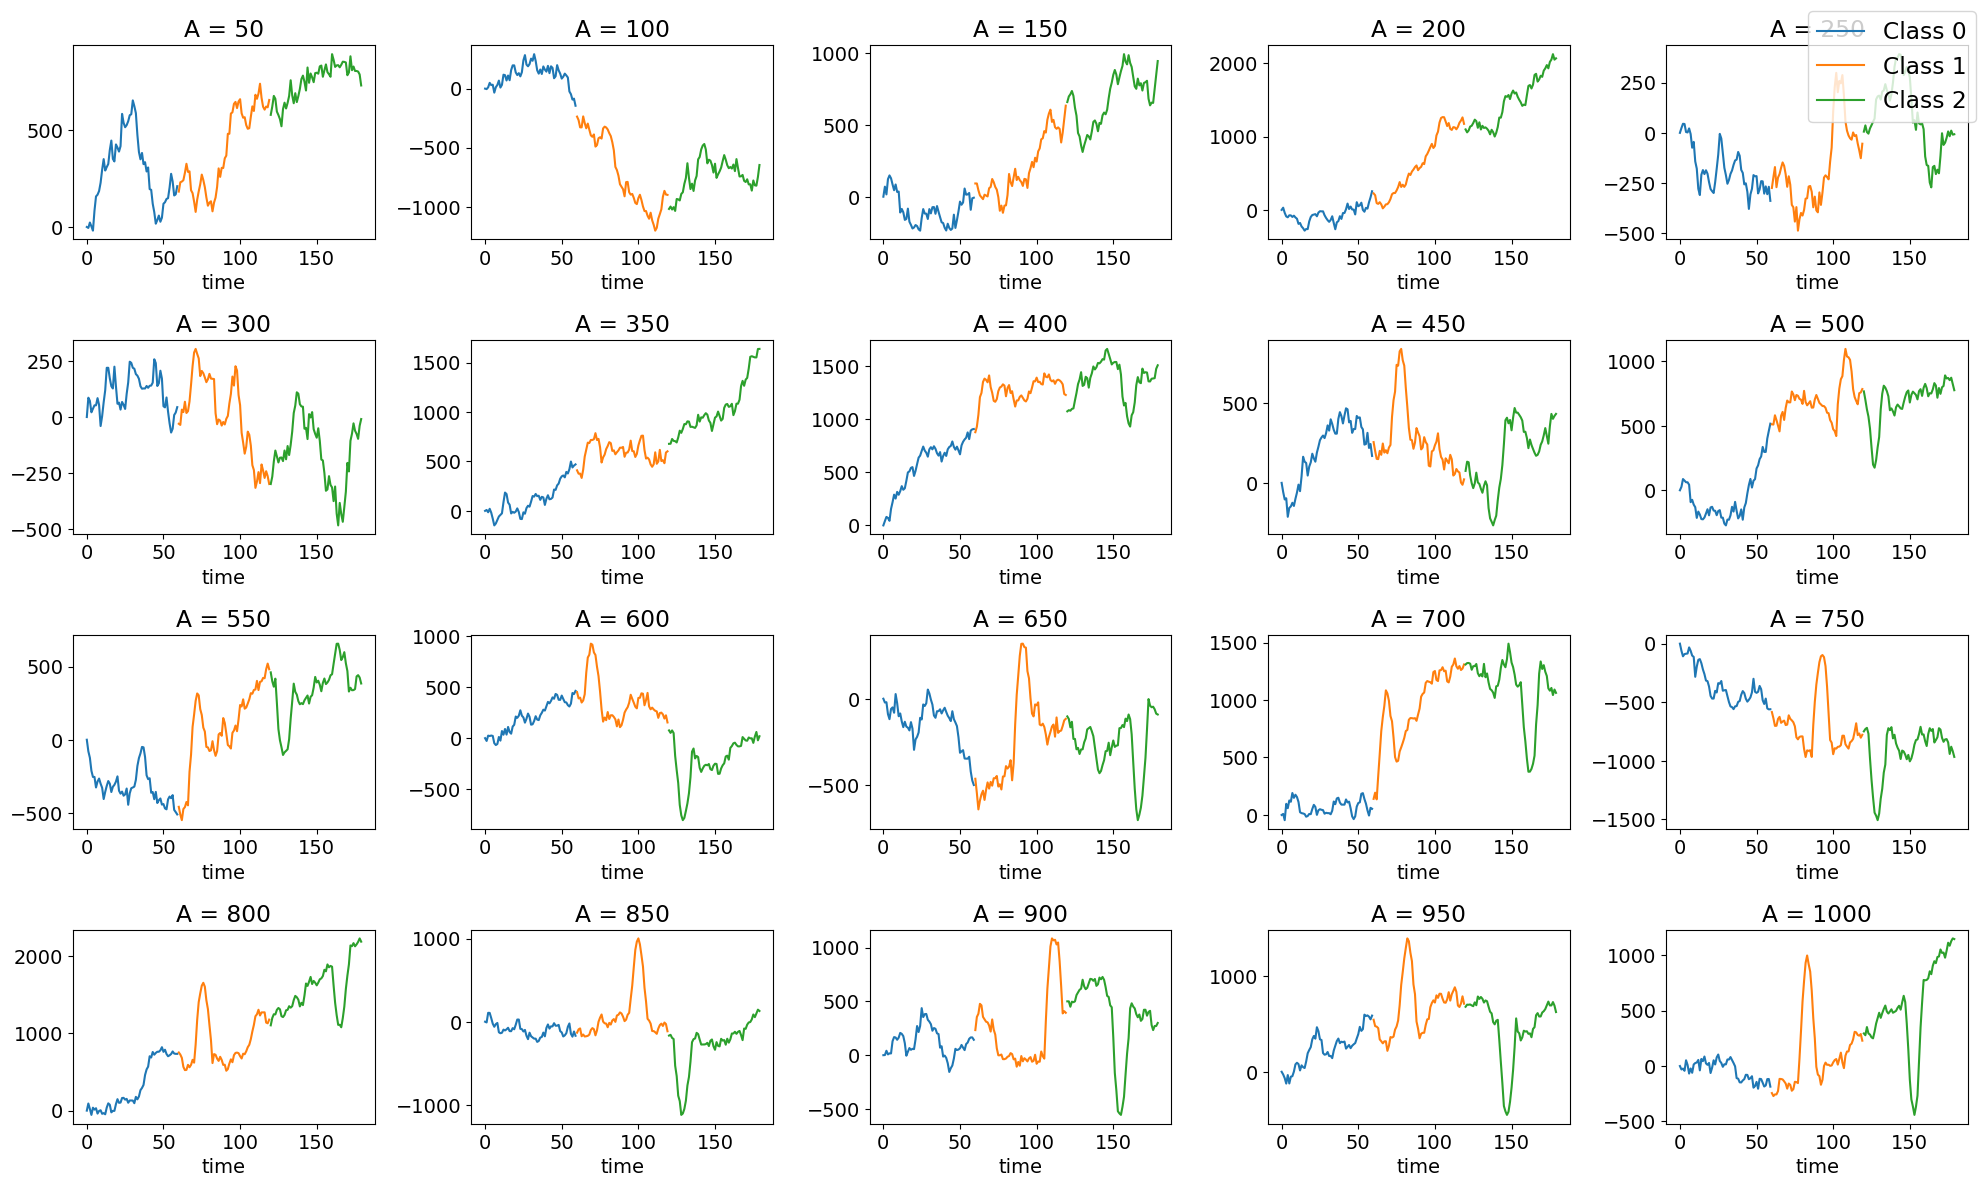

ts_L60_Z12_A1000_DX50_bias5_N10000.dat


In [6]:
# List of different values for A
Arange=np.arange(50,1050,50)

# Parameters for the Plot
num_plots = len(Arange)
cols = 5
rows = (num_plots + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(20, 3 * rows))
axes = axes.flatten()
current_plot_idx = 0

Z=12
jump = lambda drift, stdev: int(np.random.normal(drift,stdev))

# Generation of list of diferent amplitudes
for A in Arange:
    N=10000
    L=60
    DX = 50 
    bias = 5 

    y = [0] * N # initialize class labels with zeros
    x = [[0] * L for i in range(N)] # initialize timeseries with zeros

    for i in range(N):
        if i>0:
            x[i][0] = x[i-1][-1] + jump(bias,DX) # first step of the new sample starts from the last point of the previous one

        for j in range(1,L):
            x[i][j] = x[i][j-1] + jump(bias,DX) # random walk with bias

        y[i] = i%3 # assign class labels
        if y[i]>0:
            j0 = np.random.randint(0,L-1-Z) # random starting point for the pattern
            sign = 3-2*y[i] # sign of the pattern: + for class 1, - for class 2
            for j in range(Z):
                x[i][j0+j] += sign*pattern(j,Z,A) # add pattern to the timeseries

    Show_data_multi(x,L,"original data")

    str0 = f'ts_L{L}_Z{Z}_A{A}_DX{DX}_bias{bias}_N{N}.dat'
    print(str0)
    fname='DATA/x_'+str0
    np.savetxt(fname,x,fmt="%d")
    fname='DATA/y_'+str0
    np.savetxt(fname,y,fmt="%d")

In [7]:
def prepare_data_for_cnn(x, y, n_class, perc_train=0.8):
    
    x = np.array(x, dtype=float)
    y = np.array(y)
    
    N = len(x)
    L = x.shape[1] if len(x.shape) > 1 else len(x[0])
    
    # split into training and validation sets
    N_train = int(perc_train * N)
    x_train = x[:N_train]
    y_train = y[:N_train]
    
    x_val = x[N_train:]
    y_val = y[N_train:]
    N_val = len(x_val)
    
    xm_train = x_train.mean(axis=1)
    std_train = x_train.std(axis=1)
    xm_val = x_val.mean(axis=1)
    std_val = x_val.std(axis=1)
    
    print('std_train (max, min, mean):', max(std_train), min(std_train), std_train.mean(axis=0))
    print('std_val (max, min, mean):', max(std_val), min(std_val), std_val.mean(axis=0))

    # rescale with variance on the training set
    std_mean_train = std_train.mean(axis=0)
    for i in range(N_train):
         x_train[i] = (x_train[i] - xm_train[i]) / std_mean_train

    std_mean_val = std_val.mean(axis=0)
    for i in range(N_val):
        x_val[i] = (x_val[i] - xm_val[i]) / std_mean_val
        
    # Keras wants an additional dimension with a 1 at the end
    x_train = x_train.reshape(x_train.shape[0], L, 1)
    x_val = x_val.reshape(x_val.shape[0], L, 1)
    input_shape = (L, 1) 
    
    return x_train, y_train, x_val, y_val, input_shape

In [8]:
def build_cnn_model(input_shape, n_class=3, NCONV=1, NF=5):

    reg = k_reg.l2(0.2)
    ini = k_init.RandomNormal(mean=0.0, stddev=0.05, seed=None)

    model = Sequential()
    
    if NCONV == 1:
        model.add(Conv1D(filters=NF, kernel_size=11, 
                         kernel_initializer=ini, 
                         kernel_regularizer=reg,
                         activation='relu', 
                         input_shape=input_shape))
        model.add(AveragePooling1D(5))
        model.add(Conv1D(filters=5, kernel_size=7, activation='relu'))
        model.add(Flatten())
        model.add(Dense(12, activation='relu'))
        model.add(Dropout(0.2))
        
    elif NCONV == 2:
        model.add(Conv1D(filters=NF, kernel_size=11, 
                         kernel_initializer=ini, 
                         kernel_regularizer=reg,
                         activation='relu', 
                         input_shape=input_shape))
        model.add(AveragePooling1D(5))
        model.add(Flatten())
        model.add(Dense(9, activation='relu'))
        model.add(Dropout(0.2))
        model.add(Dense(6, activation='relu'))
        model.add(Dropout(0.2))

    # Output layer
    model.add(Dense(n_class, activation='softmax'))

    # Compile the model
    opt = k_opt.Adam()
    model.compile(loss=k_loss.categorical_crossentropy,
                  optimizer=opt, 
                  metrics=['accuracy'])

    
    return model

### Read data and train models

In [9]:
all_histories = [] 
Arange = np.arange(50, 1050, 50)

for a in Arange:
    str0 = f'ts_L60_Z12_A{a}_DX50_bias5_N10000.dat'
    fnamex = 'DATA/x_' + str0
    fnamey = 'DATA/y_' + str0

    x = np.loadtxt(fnamex, delimiter=" ", dtype=float)
    N, L = len(x), len(x[0])

    categ = np.loadtxt(fnamey, dtype=int)
    n_class = 3    
    print(f'Training A={a}... (Data: {N} samples)')

    y = np.zeros((N, n_class))
    for i in range(N):
        y[i][categ[i]] = 1. 
        
    x_train, y_train, x_val, y_val, input_shape = prepare_data_for_cnn(x, y, n_class=3)
        
    model_1 = build_cnn_model(input_shape=input_shape, n_class=3, NCONV=1)
    
    fit1 = model_1.fit(x_train, y_train, batch_size=BATCH_SIZE,
                       epochs=EPOCHS,
                       validation_data=(x_val, y_val),
                       verbose=0, shuffle=True) 
                       
    # Train Model 2
    reg2 = k_reg.l1(0.5)
    model_2 = clone_model(model_1)
    
    model_2.layers[0].kernel_regularizer = reg2
    model_2.layers[2].kernel_regularizer = reg2 # NB assumes NCONV=1
    
    opt2 = k_opt.Adam()
    model_2.compile(loss=k_loss.categorical_crossentropy, 
                    optimizer=opt2, 
                    metrics=['accuracy'])
    
    fit2 = model_2.fit(x_train, y_train, batch_size=BATCH_SIZE,
                       epochs=EPOCHS,
                       validation_data=(x_val, y_val), 
                       verbose=0, shuffle=True)
                       
    # Store both histories for the multiplot
    all_histories.append((fit1.history, fit2.history))

Training A=50... (Data: 10000 samples)
std_train (max, min, mean): 579.2066662446334 42.75607819038391 163.92633476977798
std_val (max, min, mean): 542.5048233272524 50.39557685617524 165.31540913961476


C:\Users\Libero\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training A=100... (Data: 10000 samples)
std_train (max, min, mean): 549.6136650715058 49.391460687945745 164.66749932221416
std_val (max, min, mean): 529.3850950762488 44.357061319353534 167.76596781032305
Training A=150... (Data: 10000 samples)
std_train (max, min, mean): 533.6807399768351 39.3015973664628 167.54986192309087
std_val (max, min, mean): 515.465840014857 43.88868178572796 168.7136825291259
Training A=200... (Data: 10000 samples)
std_train (max, min, mean): 572.4524519313567 43.48796449082844 168.506912884188
std_val (max, min, mean): 557.6467031692697 48.5362293092032 169.22766095456487
Training A=250... (Data: 10000 samples)
std_train (max, min, mean): 520.0385391701486 47.16017623188257 174.6062321569844
std_val (max, min, mean): 490.54348402789145 45.616468760988305 174.1007875219706
Training A=300... (Data: 10000 samples)
std_train (max, min, mean): 610.6378220534839 48.46440847559051 178.4402794259962
std_val (max, min, mean): 493.3409264618356 57.446922362202216 180

### Plot results

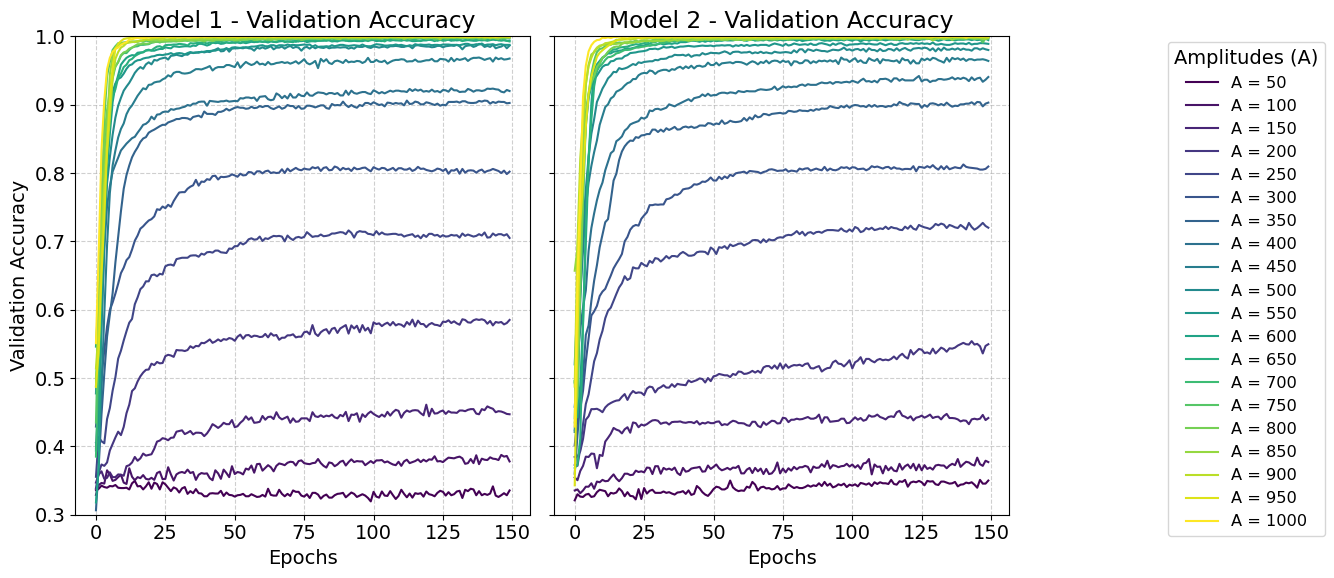

In [10]:
num_A = len(all_histories)
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
colors = cm.viridis(np.linspace(0, 1, num_A))

for idx, (hist1, hist2) in enumerate(all_histories):
    current_A = 50 + idx * 50
    
    # Plot Model 1 
    axes[0].plot(hist1['val_accuracy'], color=colors[idx], label=f'A = {current_A}', linewidth=1.5)
    
    # Plot Model 2
    axes[1].plot(hist2['val_accuracy'], color=colors[idx], label=f'A = {current_A}', linewidth=1.5)

axes[0].set_title('Model 1 - Validation Accuracy')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Validation Accuracy')
axes[0].set_ylim(0.3, 1.0) 
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].set_title('Model 2 - Validation Accuracy')
axes[1].set_xlabel('Epochs')
axes[1].grid(True, linestyle='--', alpha=0.6)

handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.12, 0.5), title="Amplitudes (A)", fontsize='small')

plt.tight_layout()
plt.subplots_adjust(right=0.85) 
plt.show()

### Conclusions (ex. 2.2)
Varying the amplitude directly affects our signal-to-noise ratio. As shown in the last plot, as A increases, the performance of our CNN improves, reducing the signal-to-noise ratio and increasing accuracy. Further architecture, hyperparameter values, data augmentation techniques etc. could be explored to make the model more robust to this kind of noise.

## Tune the regularisation (Exercise 2.3)

### Read data

Note that for this part we choose to analise a fixed amplitude ($A=350$) dataset.

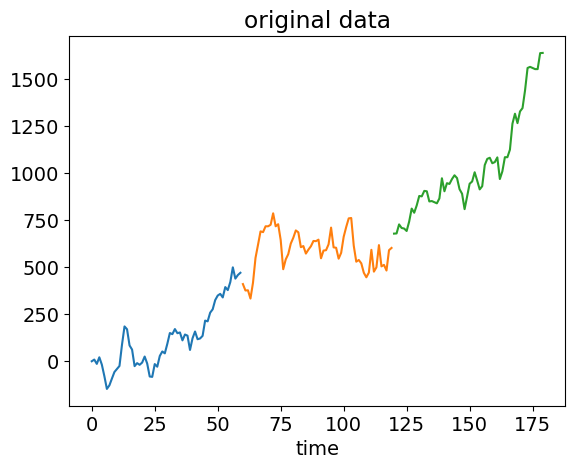

data:  10000


In [11]:
str0 = 'ts_L60_Z12_A350_DX50_bias5_N10000.dat'
fnamex='DATA/x_'+str0
fnamey='DATA/y_'+str0

x = np.loadtxt(fnamex, delimiter=" ",dtype=float)
# number of samples, number of features
N,L = len(x), len(x[0])

Show_data(x,L,"original data")

categ = np.loadtxt(fnamey, dtype=int)
n_class = 3    
print('data: ',N)

y = np.zeros((N,n_class))
for i in range(N):
    y[i][categ[i]] = 1. # y contains one-hot encoding 

### Split train-validation and rescale

(8000, 60)
N_train= 8000   N_val= 2000   L= 60   n_class= 3
std_train average and mean: 602.4695702320206 45.317947756809204 183.19389872063573
std_val average and mean: 525.141932930729 54.85085586286588 184.88091551019502


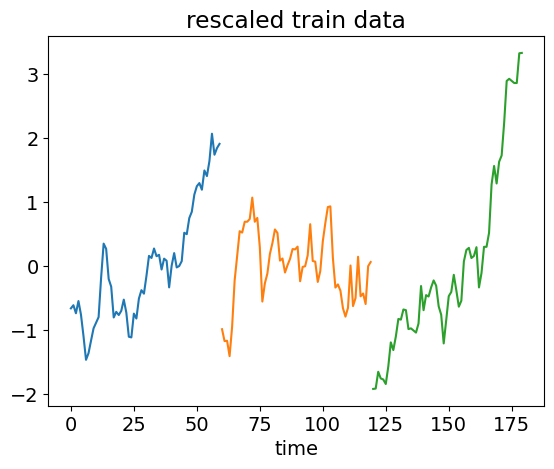

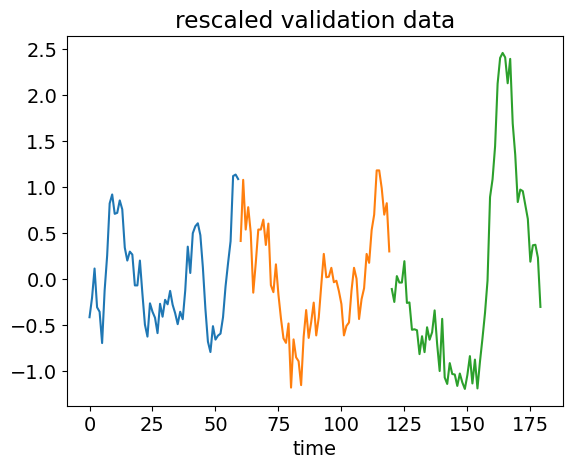

In [12]:
# split into training and validation sets
perc_train=0.8
N_train = int(perc_train*N)
x_train = x[:N_train]
print(x_train.shape)
y_train = y[:N_train]
x_val = x[N_train:]
y_val = y[N_train:]
N_val = len(x_val)
print('N_train=',N_train,'  N_val=',N_val,'  L=',L,'  n_class=',n_class)

# (two steps) rescaling
#remove average value of each sample from its values
xm_train = x_train.mean(axis=1)
std_train = x_train.std(axis=1)
xm_val = x_val.mean(axis=1)
std_val = x_val.std(axis=1)
print('std_train average and mean:',max(std_train), min(std_train), std_train.mean(axis=0))
print('std_val average and mean:',max(std_val), min(std_val), std_val.mean(axis=0))

# rescale with variance on the training set
for i in range(N_train):
     x_train[i] = (x_train[i]-xm_train[i])/ std_train.mean(axis=0)
    # NB to account for drift + varying jump length; to avoid "smoothing out" the pattern
    # (would otherwise take more time to converge / get worse loss);
for i in range(N_val):
    x_val[i] = (x_val[i]-xm_val[i])/ std_val.mean(axis=0)
    
Show_data(x_train,L,"rescaled train data")
Show_data(x_val,L,"rescaled validation data")

# Keras wants an additional dimension with a 1 at the end
x_train = x_train.reshape(x_train.shape[0], L, 1)
x_val =  x_val.reshape(x_val.shape[0], L, 1)
input_shape = (L, 1) # number of features, number of channels (1 for 1D data)

### Define functions for plotting results

In [13]:
def plot_final_accuracy(lbds, final_accs, ax, clr='black', lbl=''):
    # plot final validation accuracy for a given lambda, on a given ax (ie, a single point)
    ax.plot(lbds, final_accs, color=clr, label=lbl, marker='o', linestyle='--') # ---> (NB the linestyle)

In [14]:
def plot_noreg_acc(ax_list, acc):
    for ax in ax_list:
        ax.axhline(y=acc, color='black', linestyle='--', linewidth=0.8, label='No regularisation fin. val. acc.')

In [15]:
def plot_final_params(lbds, flat_wts, bias_arr, ax, ax_twin, l=0, shift=10**0.1, clr1='black', clr2='blue', clr3='red',
                      lbl1=f'Weights of layer', lbl2=f'Biases of layer', lbl3=f'Mean & STD of weights of layer'):
    # plot final weights (as dots of different colors) for a given lambda, on a given ax (ie multiple points aligned vertically)
    flat_wts=np.asarray(flat_wts)
    bias_arr=np.asarray(bias_arr) #---> (NB bias also multi-dim)
    
    w_std=np.std(flat_wts, axis=1)
    w_mean=np.mean(flat_wts, axis=1)
    
    # Flatten weights and repeat lambdas accordingly
    x_weights = np.repeat(lbds, flat_wts.shape[1]) 
    y_weights = flat_wts.flatten()
    ax.scatter(x_weights, y_weights, color=clr1, label=lbl1+' '+str(l))
    
    # Same for biases
    x_biases = np.repeat(lbds, bias_arr.shape[1])
    y_biases = bias_arr.flatten()
    ax.scatter(x_biases, y_biases, color=clr2, label=lbl2+' '+str(l))
    shifted_lbds=[lambda_val*shift for lambda_val in lbds]
    ax_twin.errorbar(shifted_lbds, w_mean, yerr=w_std, fmt='x', color=clr3, label=lbl3+' '+str(l))

In [16]:
def blank_final_figure(column_titles=['L1 regularisation', 'L2 regularisation'],
                       ylim_up=[0.90,1], ylim_down=[-0.8,0.8], ylim_down_r=[-0.15,0.15],
                       upgrid_on=True, downgrid_on=True):
    fig, axes = plt.subplots(2,2, figsize=(15,10))
    ((ax1,ax2),(ax3,ax4)) = axes
    ax1.set_title(column_titles[0], fontsize=16)
    ax2.set_title(column_titles[1], fontsize=16)

    ax1.set_ylabel("Final validation accuracy")
    ax3.set_xlabel('Lambda parameter')
    ax3.set_ylabel("Final weights")
    ax4.set_xlabel('Lambda parameter')
    
    for axis in fig.axes:
        axis.set_xscale('log')
    ax1.set_ylim(ylim_up)
    ax2.set_ylim(ylim_up)
    ax3.set_ylim(ylim_down)
    ax4.set_ylim(ylim_down)

    ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.8) 
    ax4.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

    ax3_twin = ax3.twinx() # set different scale for lower axes
    ax3_twin.set_ylim(ylim_down_r)   
   
    ax4_twin = ax4.twinx()
    ax4_twin.set_ylim(ylim_down_r)

    ax1.grid(upgrid_on)
    ax2.grid(upgrid_on)
    ax3.grid(downgrid_on)
    ax4.grid(downgrid_on)

    return fig, ax1,ax2,ax3,ax4, ax3_twin, ax4_twin

In [17]:
def plot_final_legend(axes_list, final_ax, location='center right', hshift=1, vshift=1):
# Combine legends from selected axes onto a single ax
    handles, labels, seen = [], [], set()
    for ax in axes_list:
        for h, l in zip(*ax.get_legend_handles_labels()):
            if l not in seen:
                seen.add(l)
                handles.append(h)
                labels.append(l)
    final_ax.legend(handles, labels, bbox_to_anchor=(hshift, vshift), loc=location)

### Create empty arrays to save training parameters

In [18]:
layers_to_save=[0] # identifying number(s) of the layer(s) of a model to save: eg. [0,1,2]

val_accs_array_l1=[[] for l in layers_to_save]
val_accs_array_l2=[[] for l in layers_to_save]
wts_array_l1=[[] for l in layers_to_save]
wts_array_l2=[[] for l in layers_to_save]
bias_array_l1=[[] for l in layers_to_save]
bias_array_l2=[[] for l in layers_to_save]

### Build & train a model with no regularisation

This will be used as a baseline for validation accuracy later.

In [19]:
og_wts_array=[[] for l in layers_to_save] 
og_bias_array=[[] for l in layers_to_save] 
model = Sequential()
print(f"=================================Doing no-reg. model=====================================")
# ---> TODO: 
if NCONV==1:
    # -----2-----
    model.add(Conv1D(filters=NF, kernel_size=11, 
                     kernel_initializer=ini,
                     activation='relu', 
                     input_shape=input_shape))
    model.add(AveragePooling1D(5))
    model.add(Conv1D(filters=5, kernel_size=7, 
                     activation='relu'))
    model.add(Flatten())
    model.add(Dense(12, activation='relu'))
    model.add(Dropout(0.2))

if NCONV==2:
    # -----1-----
    model.add(Conv1D(filters=NF, kernel_size=11, 
                     kernel_initializer=ini, 
                     activation='relu', input_shape=input_shape))
    model.add(AveragePooling1D(5))
    model.add(Flatten())
    model.add(Dense(9, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(6, activation='relu'))
    model.add(Dropout(0.2))

model.add(Dense(n_class, activation='softmax'))

opt = k_opt.Adam()

model.compile(loss=k_loss.categorical_crossentropy,
              optimizer=opt,metrics=['accuracy'])

=================================Doing no-reg. model=====================================


In [20]:
# training 
fit = model.fit(x_train,y_train,batch_size=BATCH_SIZE,
                epochs=EPOCHS,
                validation_data=(x_val, y_val),
                verbose=1, shuffle=True) 
og_val_acc=fit.history['val_accuracy'][-1] # ---> save final no-reg validation accuracy
for l in layers_to_save:
        w = model.layers[l].get_weights()[0].flatten() # weights of layer l (numpy array) ---> NB has shape
        b = model.layers[l].get_weights()[1].flatten() # bias of layer l
        og_wts_array[l].append(w)
        og_bias_array[l].append(b)

Epoch 1/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.3417 - loss: 1.0992 - val_accuracy: 0.3770 - val_loss: 1.0977
Epoch 2/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4064 - loss: 1.0945 - val_accuracy: 0.4325 - val_loss: 1.0931
Epoch 3/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4609 - loss: 1.0827 - val_accuracy: 0.4885 - val_loss: 1.0751
Epoch 4/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5054 - loss: 1.0482 - val_accuracy: 0.5375 - val_loss: 1.0218
Epoch 5/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5612 - loss: 0.9691 - val_accuracy: 0.5880 - val_loss: 0.9185
Epoch 6/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6046 - loss: 0.8797 - val_accuracy: 0.6405 - val_loss: 0.8215
Epoch 7/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6449 - loss: 0.8010 - val_accuracy: 0.6770 - val_loss: 0.7546
Epoch 8/150
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6715 - loss: 0.7544 - val_accuracy: 0.6980 - 

### Build & train model with different regularisation techniques

In [21]:
# different values of lambda parameters:
lambda_vals=[float(10**exp) for exp in range(1, -11, -1)]

reg_l1_list=[k_reg.l1(lbd) for lbd in lambda_vals] # L-1 regularisers with given lambdas
reg_l2_list=[k_reg.l2(lbd) for lbd in lambda_vals] # L-2 regularisers with given lambdas
reg_list=reg_l1_list+reg_l2_list 

In [22]:
for i in range(len(reg_list)):
    model = Sequential()
    reg=reg_list[i]
    ll=len(reg_list)
    print(f"=================================Doing model number {i+1} of {ll}=====================================")

    if NCONV==1:
        model.add(Conv1D(filters=NF, kernel_size=11, 
                         kernel_initializer=ini, 
                         kernel_regularizer=reg, # ---> loops over this
                         activation='relu', 
                         input_shape=input_shape))

        model.add(AveragePooling1D(5))
        model.add(Conv1D(filters=5, kernel_size=7, 
                         activation='relu'))
        model.add(Flatten())
        model.add(Dense(12, activation='relu'))
        model.add(Dropout(0.2))
    
    if NCONV==2:
        model.add(Conv1D(filters=NF, kernel_size=11, 
                         kernel_initializer=ini, 
                         kernel_regularizer=reg, 
                         activation='relu', input_shape=input_shape))

        model.add(AveragePooling1D(5))
        model.add(Flatten())
        model.add(Dense(9, activation='relu'))
        model.add(Dropout(0.2))
        model.add(Dense(6, activation='relu'))
        model.add(Dropout(0.2))

    model.add(Dense(n_class, activation='softmax'))
    
    opt = k_opt.Adam()
    
    # compile the model
    # categorical_crossentropy, 3 output nodes
    model.compile(loss=k_loss.categorical_crossentropy,
                  optimizer=opt,metrics=['accuracy'])
    fit = model.fit(x_train,y_train,batch_size=BATCH_SIZE,
                    epochs=EPOCHS,
                    validation_data=(x_val, y_val),
                    verbose=0, shuffle=True) 
    val_acc=fit.history['val_accuracy'][-1] # final validation accuracy
    for l in layers_to_save:
            w = model.layers[l].get_weights()[0].flatten() # weights of layer l (numpy array); careful: it has shape
            b = model.layers[l].get_weights()[1].flatten() # bias of layer l
            if (i<len(reg_l1_list)):
                val_accs_array_l1[l].append(val_acc)
                wts_array_l1[l].append(w)
                bias_array_l1[l].append(b)
            else:
                val_accs_array_l2[l].append(val_acc)
                wts_array_l2[l].append(w)
                bias_array_l2[l].append(b)

=================================Doing model number 1 of 24=====================================
=================================Doing model number 2 of 24=====================================
=================================Doing model number 3 of 24=====================================
=================================Doing model number 4 of 24=====================================
=================================Doing model number 5 of 24=====================================
=================================Doing model number 6 of 24=====================================
=================================Doing model number 7 of 24=====================================
=================================Doing model number 8 of 24=====================================
=================================Doing model number 9 of 24=====================================
=================================Doing model number 10 of 24=====================================
=============================

### Plot results

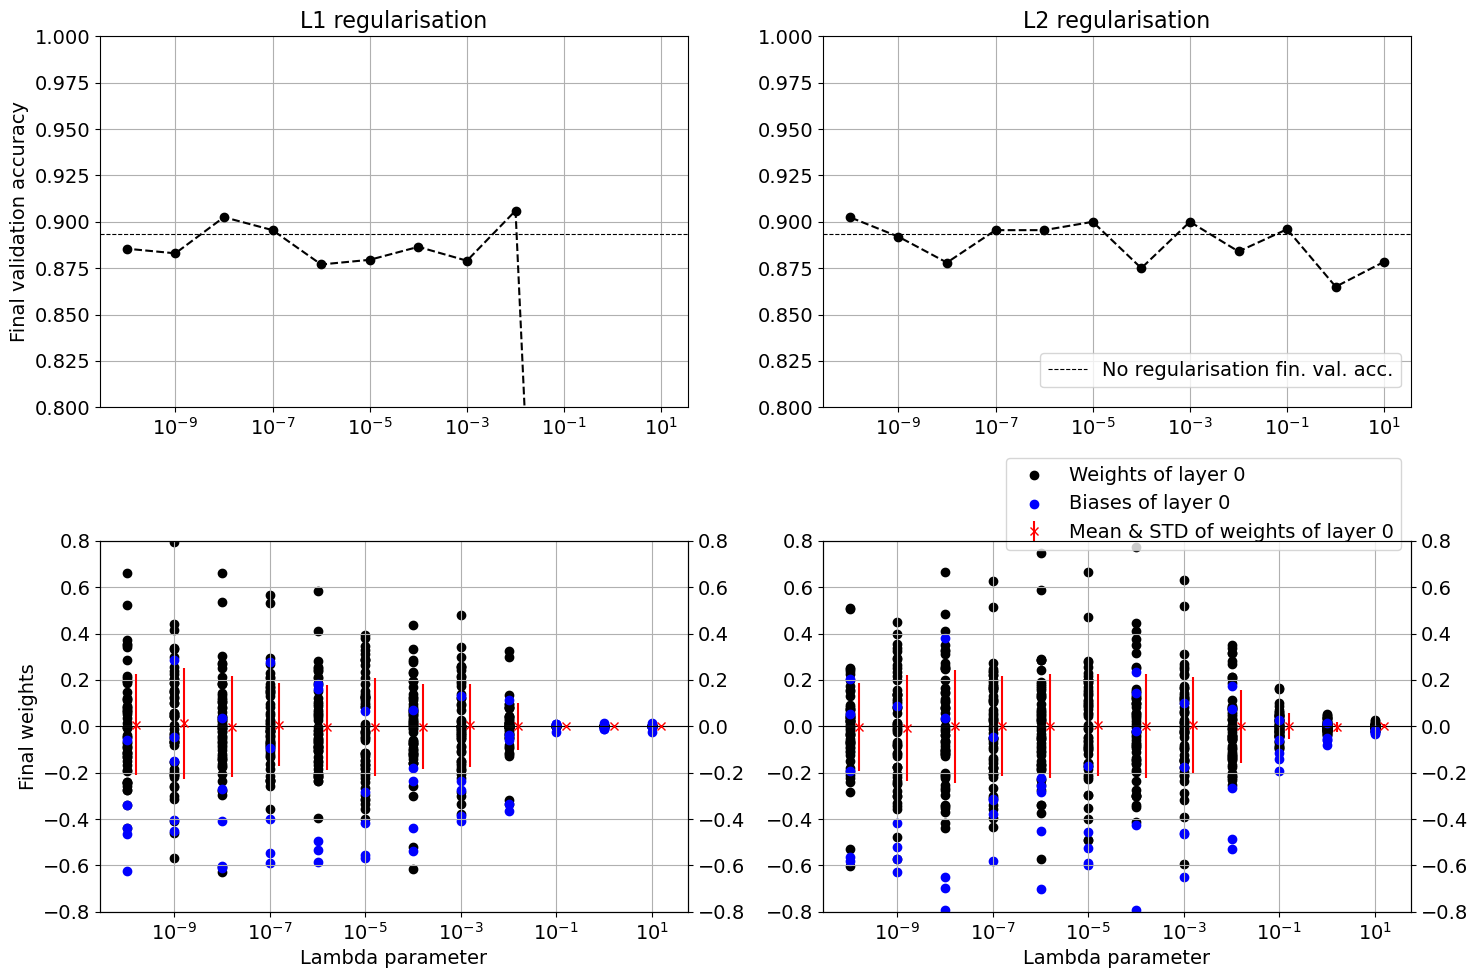

In [31]:
final_fig, ax1, ax2, ax3, ax4,ax3_twin,ax4_twin = blank_final_figure(ylim_down_r=[-0.8,0.8], ylim_up=[0.8,1])

plot_final_accuracy(lambda_vals, val_accs_array_l1[0], ax1, clr='black', lbl='') 
plot_final_accuracy(lambda_vals, val_accs_array_l2[0], ax2, clr='black', lbl='')
plot_final_params(lambda_vals, wts_array_l1[0], bias_array_l1[0], ax3, ax_twin=ax3_twin, shift=10**0.2)
plot_final_params(lambda_vals, wts_array_l2[0], bias_array_l2[0], ax4, ax_twin=ax4_twin, shift=10**0.2)
plot_noreg_acc([ax1, ax2], og_val_acc)

plot_final_legend([ax1,ax2], ax2, vshift=0.1)
plot_final_legend([ax3, ax4, ax3_twin, ax4_twin], ax4, vshift=1.1)

plt.tight_layout()  
plt.show()

### Conclusions (ex.s 2.3, 2.3.1, 2.3.2)

From this final graph, we see that both L1 and L2 types of regularisation procedures only slightly improve the validation accuracy; furthermore, no specific value for the lambda parameter should be preferred over the others (different executions of the code lead to different optimal values of this parameter).

(Note that here the mean of weights for a given lambda parameter is always very close to zero, as expected for a relatively big number of weights; therefore, the standard deviation is a good metric to quantify how big the weights are.)

More interestingly, from the lower plots we see that, as the lambda parameter gets bigger than about $~10^{-3}$, the weights of the CNN (here of the first layer, but we have observed similar results for the other layers) become smaller, and tend to zero in the L1 case (*sparsity*). This is expected considering the (squared) norm of weights included in the L1 (L2) regularisation term by definition. What is more (and a bit more difficult to see to the unaided eye), L2 regularisation, which is the weaker of the two kinds, leads to slightly larger weights than L1, also expected from theory.

However, interestingly, we observe that the biases also go to zero, despite not being explicitely involved in the regularisation. One possible, hand-waving explanation is that, as weights are forced to get smaller, biases tend to vary in the same order of magnitude, so that data is classified basing on all parameters (if it were classified basing mostly on biases, the model would be using significantly less of its expressive power).